In [22]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

Loading DataSet

In [60]:
df=pd.read_csv("diabetes.csv")

Handling Missing Data 

<Axes: >

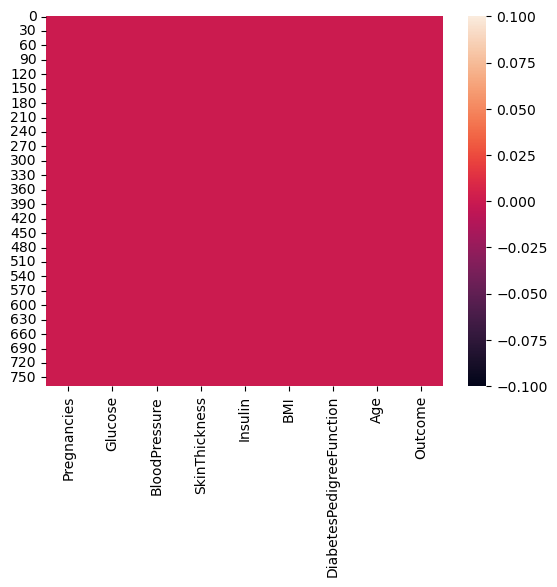

In [63]:
sns.heatmap(df.isnull())

Correlation Matrix

In [66]:
Corr=df.corr()
print(Corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

<Axes: >

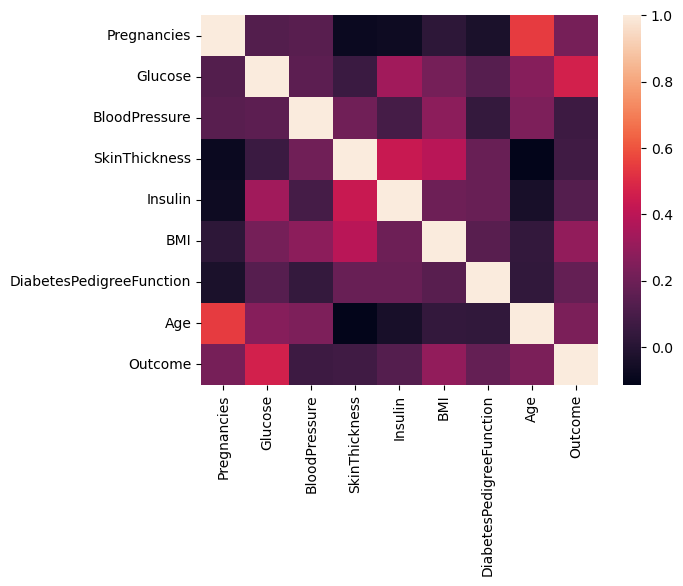

In [68]:
sns.heatmap(Corr)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [72]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Checking Null Value

In [75]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Checking Duplicate Values

In [78]:
df.duplicated().sum()

0

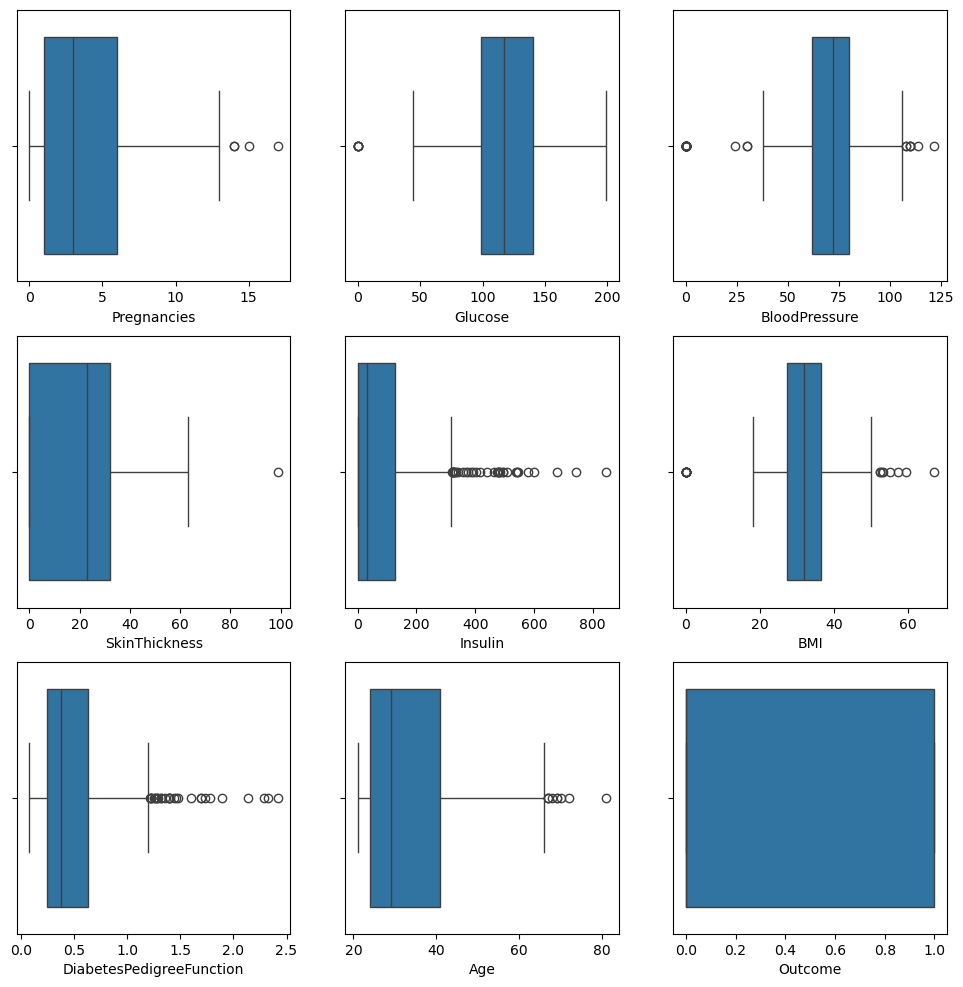

In [88]:
plt.figure(figsize = (12,12))
for i, col in enumerate(["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]):
    plt.subplot(3,3, i+1)
    sns.boxplot(x= col, data= df)
plt.show()

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Train All The Models 

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import joblib

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM":                 SVC(probability=True),
    "Decision Tree":       DecisionTreeClassifier(),
    "Neural Network":      MLPClassifier(max_iter=500)
}

best_acc   = 0
best_name  = ""
best_model = None

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: {acc:.2%}")
    if acc > best_acc:
        best_acc, best_name, best_model = acc, name, model

print(f"\nBest model: {best_name} ({best_acc:.2%})")

Logistic Regression: 75.32%
SVM: 73.38%
Decision Tree: 76.62%
Neural Network: 74.68%

Best model: Decision Tree (76.62%)


In [103]:
    import joblib

# Save every model separately
joblib.dump(models["Logistic Regression"], 'model_logreg.pkl')
joblib.dump(models["SVM"],                 'model_svm.pkl')
joblib.dump(models["Decision Tree"],       'model_dt.pkl')
joblib.dump(models["Neural Network"],      'model_nn.pkl')

# Save the scaler once — same scaler works for all models
joblib.dump(scaler, 'scaler.pkl')

print("All 4 models saved!")

All 4 models saved!
